<a href="https://colab.research.google.com/github/islam3ouf/Linear-Algebra-Visualization-With-Python/blob/main/01-Vector-Visualization/notebooks/static_vector_operations.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

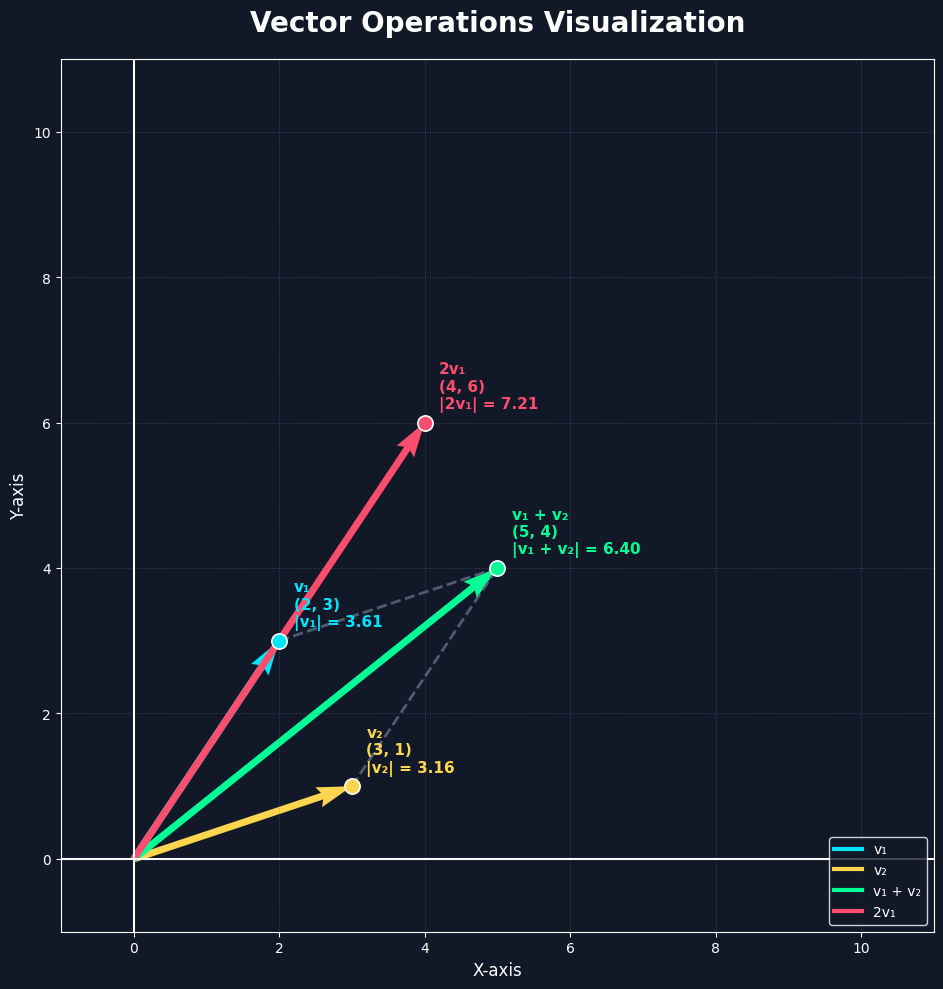

In [3]:
"""
Vector Operations Visualization
===============================

Static visualization of:

1. Vector Addition
2. Scalar Multiplication

Author: Islam Ouff
"""

from typing import Final

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D


# ============================================================
# VECTOR DATA
# ============================================================

V1: Final[np.ndarray] = np.array([2, 3])
V2: Final[np.ndarray] = np.array([3, 1])

VECTOR_SUM: Final[np.ndarray] = V1 + V2
DOUBLE_V1: Final[np.ndarray] = 2 * V1


# ============================================================
# COLORS
# ============================================================

BACKGROUND_COLOR: Final[str] = "#111827"

VECTOR1_COLOR: Final[str] = "#00E5FF"
VECTOR2_COLOR: Final[str] = "#FFD54F"
SUM_COLOR: Final[str] = "#00FF95"
SCALED_COLOR: Final[str] = "#FF4D6D"

GRID_COLOR: Final[str] = "#64748B"
TEXT_COLOR: Final[str] = "white"


# ============================================================
# FIGURE SETTINGS
# ============================================================

FIGURE_SIZE: Final[tuple[int, int]] = (10, 10)

X_LIMITS: Final[tuple[int, int]] = (-1, 11)
Y_LIMITS: Final[tuple[int, int]] = (-1, 11)

VECTOR_WIDTH: Final[float] = 0.008

POINT_SIZE: Final[int] = 120


# ============================================================
# FIGURE
# ============================================================

def create_figure() -> tuple[plt.Figure, plt.Axes]:
    """
    Create and configure the matplotlib figure.

    Returns
    -------
    tuple[plt.Figure, plt.Axes]
        The created figure and axes.
    """

    plt.style.use("dark_background")

    fig, ax = plt.subplots(
        figsize=FIGURE_SIZE,
    )

    fig.patch.set_facecolor(BACKGROUND_COLOR)
    ax.set_facecolor(BACKGROUND_COLOR)

    return fig, ax

# ============================================================
# AXES
# ============================================================

def configure_axes(ax: plt.Axes) -> None:
    """
    Configure the coordinate system.

    Parameters
    ----------
    ax
        Target axes.
    """

    ax.set_xlim(X_LIMITS)
    ax.set_ylim(Y_LIMITS)

    ax.set_aspect("equal")

    ax.axhline(
        0,
        color=TEXT_COLOR,
        linewidth=1.5,
    )

    ax.axvline(
        0,
        color=TEXT_COLOR,
        linewidth=1.5,
    )

    ax.grid(
        color=GRID_COLOR,
        linestyle=":",
        linewidth=0.7,
        alpha=0.5,
    )

    ax.set_xlabel(
        "X-axis",
        fontsize=12,
        color=TEXT_COLOR,
    )

    ax.set_ylabel(
        "Y-axis",
        fontsize=12,
        color=TEXT_COLOR,
    )

    ax.set_title(
        "Vector Operations Visualization",
        fontsize=20,
        fontweight="bold",
        color=TEXT_COLOR,
        pad=20,
    )

# ============================================================
# DRAWING HELPERS
# ============================================================

def vector_magnitude(vector: np.ndarray) -> float:
    """
    Compute the Euclidean magnitude of a vector.

    Parameters
    ----------
    vector
        Input vector.

    Returns
    -------
    float
        Vector magnitude.
    """

    return float(np.linalg.norm(vector))


def vector_coordinates(
    vector: np.ndarray,
) -> str:
    """
    Format vector coordinates.

    Parameters
    ----------
    vector
        Input vector.

    Returns
    -------
    str
        Formatted coordinate string.
    """

    return (
        f"({vector[0]}, "
        f"{vector[1]})"
    )


def draw_vector(
    ax: plt.Axes,
    vector: np.ndarray,
    color: str,
    label: str,
) -> None:
    """
    Draw a vector from the origin with its endpoint,
    label, coordinates, and magnitude.

    Parameters
    ----------
    ax
        Target axes.

    vector
        Vector to draw.

    color
        Vector color.

    label
        Vector name.
    """

    ax.quiver(
        0,
        0,
        vector[0],
        vector[1],
        angles="xy",
        scale_units="xy",
        scale=1,
        color=color,
        width=VECTOR_WIDTH,
    )

    ax.scatter(
        vector[0],
        vector[1],
        s=POINT_SIZE,
        color=color,
        edgecolors=TEXT_COLOR,
        linewidth=1.2,
        zorder=5,
    )

    text = (
        f"{label}\n"
        f"{vector_coordinates(vector)}\n"
        f"|{label}| = {vector_magnitude(vector):.2f}"
    )

    ax.text(
        vector[0] + 0.20,
        vector[1] + 0.20,
        text,
        fontsize=11,
        fontweight="bold",
        color=color,
    )


# ============================================================
# VECTOR ADDITION
# ============================================================

def draw_parallelogram(
    ax: plt.Axes,
    vector1: np.ndarray,
    vector2: np.ndarray,
    resultant: np.ndarray,
) -> None:
    """
    Draw the helper lines of the parallelogram rule.

    Parameters
    ----------
    ax
        Target axes.

    vector1
        First vector.

    vector2
        Second vector.

    resultant
        Resultant vector.
    """

    ax.plot(
        [vector1[0], resultant[0]],
        [vector1[1], resultant[1]],
        "--",
        color=GRID_COLOR,
        linewidth=2,
        alpha=0.75,
    )

    ax.plot(
        [vector2[0], resultant[0]],
        [vector2[1], resultant[1]],
        "--",
        color=GRID_COLOR,
        linewidth=2,
        alpha=0.75,
    )


# ============================================================
# LEGEND
# ============================================================

def create_legend(ax: plt.Axes) -> None:
    """
    Create the figure legend.
    """

    handles = [
        Line2D(
            [0],
            [0],
            color=VECTOR1_COLOR,
            lw=3,
            label="v₁",
        ),
        Line2D(
            [0],
            [0],
            color=VECTOR2_COLOR,
            lw=3,
            label="v₂",
        ),
        Line2D(
            [0],
            [0],
            color=SUM_COLOR,
            lw=3,
            label="v₁ + v₂",
        ),
        Line2D(
            [0],
            [0],
            color=SCALED_COLOR,
            lw=3,
            label="2v₁",
        ),
    ]

    ax.legend(
        handles=handles,
        loc="lower right",
        facecolor=BACKGROUND_COLOR,
        edgecolor=TEXT_COLOR,
        fontsize=10,
        labelcolor=TEXT_COLOR,
    )

# ============================================================
# DRAW ALL VECTORS
# ============================================================

def draw_all_vectors(ax: plt.Axes) -> None:
    """
    Draw all vectors included in the visualization.
    """

    vectors = [
        (V1, VECTOR1_COLOR, "v₁"),
        (V2, VECTOR2_COLOR, "v₂"),
        (VECTOR_SUM, SUM_COLOR, "v₁ + v₂"),
        (DOUBLE_V1, SCALED_COLOR, "2v₁"),
    ]

    for vector, color, label in vectors:
        draw_vector(
            ax=ax,
            vector=vector,
            color=color,
            label=label,
        )


# ============================================================
# MAIN
# ============================================================

def main() -> None:
    """
    Generate the static vector operations visualization.
    """

    fig, ax = create_figure()

    configure_axes(ax)

    draw_all_vectors(ax)

    draw_parallelogram(
        ax=ax,
        vector1=V1,
        vector2=V2,
        resultant=VECTOR_SUM,
    )

    create_legend(ax)

    fig.tight_layout()

    plt.show()


if __name__ == "__main__":
    main()